# 전처리 & 머신러닝 통합 개인과제

## Part 2. 구매 고객 특성 분석 및 시각화

### 실무 시나리오

전자상거래 기업의 CRM팀은 모든 고객에게 동일한 프로모션을 제공하면서 마케팅 비용이 증가하고 있습니다.  
이에 데이터 분석팀은 Part 1에서 정제한 고객 데이터를 활용하여 **구매율과 구매금액이 높은 고객군을 찾고, 고객의 구매 행동을 설명할 수 있는 주요 변수를 확인**하려고 합니다.

수강생은 데이터 분석 담당자로서 다음 업무를 수행합니다.

1. 고객군별 구매 특성을 비교합니다.
2. 구매 행동의 분포와 변수 간 관계를 시각화합니다.
3. 분석 결과를 바탕으로 Part 3 구매예측 모델에 사용할 Feature 후보를 정리합니다.

> 문제 1~3은 필수 문제입니다.  
> 문제 4는 추가 분석을 위한 심화 문제이며 선택적으로 수행합니다.  
> 차트 종류와 표현 방식은 정해진 하나의 답만 있는 것이 아닙니다. 분석 목적에 적절하고 제목·축·범례가 명확하면 인정합니다.

## 과제 목표

- 전처리된 데이터의 주요 구매 현황을 확인할 수 있습니다.
- 두 개 이상의 기준으로 고객 데이터를 집계하고 집단별 구매 차이를 설명할 수 있습니다.
- 분석 목적에 적합한 차트를 선택하고 기본 시각 요소를 설정할 수 있습니다.
- EDA 결과를 근거로 머신러닝 Feature 후보를 제안할 수 있습니다.

## 사용 환경 및 데이터

- Python 3.X
- pandas, numpy
- `전자상거래_고객구매_전처리완료.csv`

# 문제 1. 주요 고객군의 구매 특성 비교

## 업무 상황

CRM팀은 프로모션 대상을 정하기 위해 어떤 고객군의 구매율과 구매금액이 높은지 확인하려고 합니다.  
전체 평균만 확인하면 집단별 차이를 알기 어렵기 때문에, 고객 특성을 기준으로 구매 실적을 비교해야 합니다.

## 필수 요구사항

1. 전처리 완료 데이터를 불러오고 데이터 크기와 주요 컬럼을 확인하세요.
2. 전체 고객 수, 구매 고객 수, 구매율과 주요 수치형 변수의 기초 통계량을 확인하세요.
3. 회원등급, 지역, 연령대, 선호 카테고리 중 적절한 기준을 선택하여 고객군별 구매 특성을 집계하세요.
4. **두 개 이상의 기준을 함께 사용한 그룹 집계**를 1개 이상 수행하세요.
5. 집계 결과를 바탕으로 구매율 또는 평균 구매금액이 높은 고객군을 간단히 설명하세요.

## 힌트

- 고객 수, 구매 고객 수, 구매율, 평균 구매금액, 평균 방문횟수 등을 집계 지표로 활용할 수 있습니다.
- 구매율이 높더라도 고객 수가 매우 적다면 해석에 주의해야 합니다.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

DATA_PATH = Path("전자상거래_고객구매_전처리완료.csv")

# TODO: 전처리 완료 데이터를 불러와 df에 저장하세요.
df = pd.read_csv(DATA_PATH)

# TODO: 데이터 크기, 주요 컬럼과 앞부분을 확인하세요.
print(df.shape)
print(df.columns)
display(df.head())

(1500, 17)
Index(['CustomerID', 'Gender', 'Age', 'Region', 'MembershipLevel',
       'VisitCount', 'AveragePurchaseAmount', 'TotalPurchaseAmount',
       'SatisfactionScore', 'LastPurchaseDate', 'CouponUsed',
       'PreferredCategory', 'SignupDate', 'Email', 'PurchaseStatus',
       'AgeGroup', 'PurchaseGrade'],
      dtype='str')


,CustomerID,Gender,Age,Region,MembershipLevel,VisitCount,AveragePurchaseAmount,TotalPurchaseAmount,SatisfactionScore,LastPurchaseDate,CouponUsed,PreferredCategory,SignupDate,Email,PurchaseStatus,AgeGroup,PurchaseGrade
0,CUST101486,Female,40.0,Seoul,Silver,5,75000.0,139800.0,3.7,2026-02-07,0,Beauty,2022-12-03,customer1486@example.com,0,40대,낮음
1,CUST100113,Male,39.0,Gyeonggi,Basic,7,74400.0,159200.0,4.8,2026-04-22,0,Home,2021-07-16,customer113@example.com,1,30대,낮음
2,CUST100168,Male,69.5,Gwangju,Silver,12,185800.0,1055800.0,4.5,2026-06-06,0,Beauty,2022-02-15,customer168@example.com,1,60대 이상,높음
3,CUST101212,Male,44.0,Daegu,VIP,7,153900.0,413200.0,4.5,2026-05-07,0,Home,2021-10-27,customer1212@example.com,1,40대,중간
4,CUST100312,Male,37.0,Gyeonggi,Basic,14,123700.0,576000.0,4.0,2026-04-16,0,Home,2025-11-08,customer312@example.com,1,30대,높음


In [2]:
# TODO: 전체 고객 수, 구매 고객 수, 구매율과 주요 수치형 변수의 기초 통계량을 확인하세요.
total_customers = len(df)
purchase_customers = len(df[df["PurchaseStatus"] == 1])
purchase_rate = purchase_customers / total_customers * 100

print("전체 고객 수:", total_customers)
print("구매 고객 수:", purchase_customers)
print("구매율:", purchase_rate)

display(df[
    [
        "Age",
        "VisitCount",
        "AveragePurchaseAmount",
        "TotalPurchaseAmount",
        "SatisfactionScore"
    ]
].describe())

전체 고객 수: 1500
구매 고객 수: 733
구매율: 48.86666666666667


,Age,VisitCount,AveragePurchaseAmount,TotalPurchaseAmount,SatisfactionScore
count,1500.000000,1500.000000,1500.000000,1.500000e+03,1500.000000
mean,39.413667,9.050000,120057.533333,3.888998e+05,3.662600
std,10.672175,2.943004,51559.879750,2.604137e+05,0.746194
min,18.000000,1.000000,5000.000000,5.000000e+03,1.700000
25%,32.000000,7.000000,83975.000000,1.864250e+05,3.200000
50%,39.000000,9.000000,117500.000000,3.360500e+05,3.700000
75%,47.000000,11.000000,149750.000000,5.360250e+05,4.200000
max,69.500000,17.000000,248412.500000,1.060425e+06,5.000000


In [3]:
# TODO: 고객 특성 한 가지를 기준으로 구매 특성을 집계하세요.
print("회원 등급별 고객 수\n", df["MembershipLevel"].value_counts())

membership_result = df.groupby("MembershipLevel")[
    ["PurchaseStatus", "AveragePurchaseAmount", "VisitCount"]
].mean()

display("회원 등급별 구매 특성", membership_result)

# TODO: 두 개 이상의 기준을 함께 사용하여 그룹 집계를 수행하세요.
group_result = df.groupby(["MembershipLevel", "AgeGroup"])[
    ["PurchaseStatus", "AveragePurchaseAmount"]
].mean()

display("회원 등급 및 연령대별 구매 특성", group_result)

회원 등급별 고객 수
 MembershipLevel
Basic     697
Silver    419
Gold      276
VIP       108
Name: count, dtype: int64


'회원 등급별 구매 특성'

,PurchaseStatus,AveragePurchaseAmount,VisitCount
MembershipLevel,,,
Basic,0.426112,97926.111908,9.064562
Gold,0.605072,149213.134058,9.003623
Silver,0.431981,118823.180191,9.095465
VIP,0.814815,193167.245370,8.898148


'회원 등급 및 연령대별 구매 특성'

PurchaseStatus  AveragePurchaseAmount
MembershipLevel AgeGroup                                       
Basic           20대 이하          0.389831           95854.237288
                30대             0.399194           96255.241935
                40대             0.422727          103089.545455
                50대             0.566667           94422.222222
                60대 이상          0.380952           90223.809524
Gold            20대 이하          0.571429          145255.357143
                30대             0.659574          154096.010638
                40대             0.575000          148188.750000
                50대             0.606061          139978.787879
                60대 이상          0.538462          160700.000000
Silver          20대 이하          0.422535          114629.577465
                30대             0.468531          124989.597902
                40대             0.389313          112522.900763
                50대             0.457627          122681.355932
                60대 이상          0.400000          119733.333333
VIP             20대 이하          0.916667          190357.291667
                30대             0.769231          193177.243590
                40대             0.750000          196557.812500
                50대             1.000000          196328.125000
                60대 이상          0.800000          179820.000000

### 문제 1 결과 정리

- 전체 구매 현황: 전체 고객 1500명 중 733명으로 구매율은 48.9%로 나타남.
- 구매율이 높은 고객군: VIP가 81.5%로 가장 높게 나타났으나 전체 인원 대비 비중이 작아서 해석 시 주의가 필요함. 인원 수까지 고려한다면 Gold가 60.5%로 구매율이 높은 고객군으로 볼 수 있음.
- 평균 구매금액이 높은 고객군: VIP가 193167원으로 가장 높음.
- 고객 수를 함께 고려했을 때 주의할 점: 그룹이 세분화될수록 표본 수가 적어져서 비율이 과대평가될 수 있으므로 항상 비율과 실제 인원 수를 교차 검증하여 왜곡을 방지해야 함.


# 문제 2. 구매 행동의 분포와 관계 시각화

## 업무 상황

고객군별 평균만으로는 실제 데이터가 어느 구간에 집중되어 있는지, 일부 극단값이 평균에 영향을 주는지 알기 어렵습니다.  
CRM팀이 결과를 쉽게 이해할 수 있도록 구매 행동의 분포, 고객군 간 차이, 변수 간 관계를 시각화해야 합니다.

## 필수 요구사항

1. 구매금액, 방문횟수, 만족도 등 주요 수치형 변수 중 하나 이상의 분포를 시각화하세요.
2. 회원등급, 구매 여부 등 고객 집단별 차이를 비교할 수 있는 차트를 작성하세요.
3. 두 수치형 변수의 관계를 확인할 수 있는 차트를 작성하세요.
4. 모든 차트에 분석 내용을 이해할 수 있는 제목과 축 이름을 표시하고, 필요한 경우 범례를 추가하세요.
5. 차트에서 확인한 주요 패턴을 간단히 설명하세요.

## 힌트

- 분포 확인에는 히스토그램이나 박스플롯을 사용할 수 있습니다.
- 집단 비교에는 막대그래프나 그룹별 박스플롯을 사용할 수 있습니다.
- 수치형 변수 관계에는 산점도를 사용할 수 있습니다.

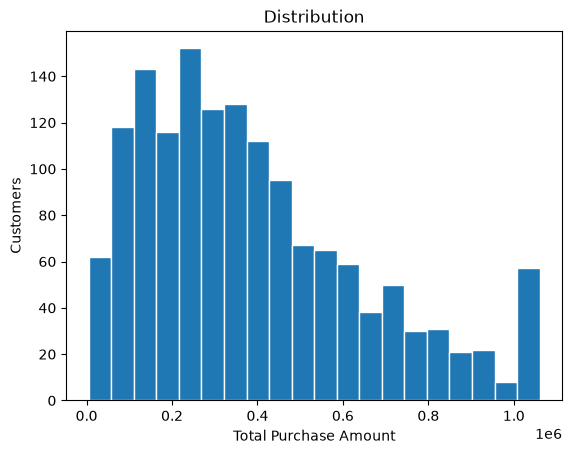

In [5]:
# TODO: 주요 수치형 변수의 분포를 시각화하세요.
plt.hist(df["TotalPurchaseAmount"].dropna(), bins=20, edgecolor="white")

plt.xlabel("Total Purchase Amount")
plt.ylabel("Customers")
plt.title("Distribution")

plt.show()

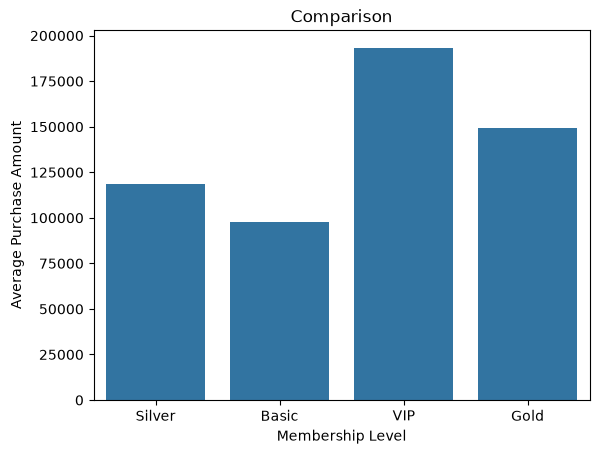

In [6]:
# TODO: 고객 집단별 구매 차이를 비교하는 차트를 작성하세요.
sns.barplot(
    data=df,
    x="MembershipLevel",
    y="AveragePurchaseAmount",
    errorbar=None
)

plt.xlabel("Membership Level")
plt.ylabel("Average Purchase Amount")
plt.title("Comparison")

plt.show()

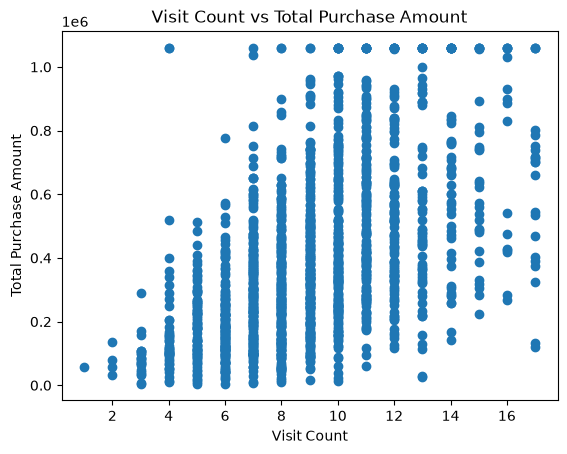

In [8]:
# TODO: 두 수치형 변수의 관계를 확인하는 차트를 작성하세요.
plt.scatter(
    df["VisitCount"],
    df["TotalPurchaseAmount"]
)

plt.xlabel("Visit Count")
plt.ylabel("Total Purchase Amount")
plt.title("Visit Count vs Total Purchase Amount")

plt.show()

### 문제 2 결과 정리

- 주요 변수의 분포 특징: 총 구매 금액이 높아질수록 고객 수가 전반적으로 감소하는 형태를 보임. 가장 높은 구매 금액의 고객이 증가한 것은 극단값을 최댓값으로 처리하는 과정에서 발생한 것으로 확인됨.
- 고객 집단별 차이: 멤버십 등급이 높을수록 평균 구매 금액이 상승하는 경향이 보임.
- 두 변수 사이에서 확인한 관계: 방문 횟수와 총 구매 금액은 양의 상관관계를 보이나 방문 횟수가 커질수록 구매 금액의 분산이 넓어지는 현상이 보임.
- 시각화 결과가 고객 분석에 주는 의미: 방문 횟수와 멤버십 등급이 매출과 관련이 있는 것으로 보이기 때문에 고객 특성 분석에 활용될 수 있음.


# 문제 3. 구매예측 모델링 Feature 후보 정리

## 업무 상황

Part 3에서는 고객의 구매 여부를 예측하는 머신러닝 모델을 개발합니다.  
모델에 모든 컬럼을 그대로 넣기보다, 이번 EDA에서 구매 행동과 관련성이 확인된 변수와 제외해야 할 변수를 구분해야 합니다.

## 필수 요구사항

1. 수치형 변수와 `PurchaseStatus`의 관계를 확인할 수 있는 표 또는 시각화를 작성하세요.
2. 문제 1과 문제 2의 분석 결과를 바탕으로 모델링에 사용할 Feature 후보를 정리하세요.
3. 고객 식별자처럼 일반적인 구매 패턴 학습에 적절하지 않은 컬럼을 제외 후보로 구분하세요.
4. 각 Feature 후보를 선정한 근거를 EDA 결과와 연결하여 간단히 설명하세요.

## 힌트

- 상관계수는 수치형 변수 사이의 선형 관계를 확인하는 참고 자료입니다.
- 상관계수가 낮더라도 범주형 변수나 비선형 관계를 가진 변수는 모델에 유용할 수 있습니다.
- 고객 ID와 같은 고유 식별자는 새로운 고객의 구매 패턴을 일반화하는 데 적절하지 않을 수 있습니다.

In [9]:
# TODO: 수치형 변수와 PurchaseStatus의 관계를 확인하세요.
numeric_cols = [
    "Age",
    "VisitCount",
    "AveragePurchaseAmount",
    "TotalPurchaseAmount",
    "SatisfactionScore",
    "CouponUsed",
    "PurchaseStatus"
]

corr = df[numeric_cols].corr()

print(corr["PurchaseStatus"])

Age                      0.024662
VisitCount               0.244498
AveragePurchaseAmount    0.322867
TotalPurchaseAmount      0.379958
SatisfactionScore        0.170412
CouponUsed               0.073426
PurchaseStatus           1.000000
Name: PurchaseStatus, dtype: float64


In [11]:
# TODO: EDA 결과를 바탕으로 Feature 후보와 제외 후보를 정리하세요.
numeric_features = [
    "VisitCount",
    "AveragePurchaseAmount",
    "TotalPurchaseAmount",
    "SatisfactionScore"
]

categorical_features = [
    "MembershipLevel",
    "AgeGroup"
]

exclude_columns = [
    "CustomerID",
    "Email",
    "PurchaseStatus"
]

print("수치형 Feature:", numeric_features)
print("\n범주형 Feature:", categorical_features)
print("\n제외 후보:", exclude_columns)

수치형 Feature: ['VisitCount', 'AveragePurchaseAmount', 'TotalPurchaseAmount', 'SatisfactionScore']

범주형 Feature: ['MembershipLevel', 'AgeGroup']

제외 후보: ['CustomerID', 'Email', 'PurchaseStatus']


### 문제 3 결과 정리

#### 모델링 Feature 후보

- 수치형 Feature: VisitCount, AveragePurchaseAmount, TotalPurchaseAmount, SatisfactionScore
- 범주형 Feature: MembershipLevel, AgeGroup
- 선정 근거: 상관관계 분석 결과 타겟 변수와 비교적 높은 상관관계를 보인 수치형 변수들로 선정. 문제 1에서 회원 등급과 연령대에 따라 구매 특성에 차이가 났으므로 MembershipLevel과 AgeGroup을 범주형 Feature 후보로 선정.

#### 제외 후보

- 제외할 컬럼: CustomerID, Email, PurchaseStatus
- 제외 이유: CustomerID와 Email은 고객 고유 식별 정보이므로 새로운 고객의 구매 패턴을 학습하는 데 부적합. PurchaseStatus는 모델이 예측해야 할 타겟 변수이므로 Feature에서는 제외.



# (심화)문제 4. 분석 결과의 심화 해석

## 업무 상황

CRM팀은 기본 분석 결과를 실제 마케팅과 구매예측 모델에 적용하기 전에,
고객군별 결과의 활용 가능성과 해석상의 주의점, 모델링 변수 구성의 위험 요소를 추가로 확인하려고 합니다.

## 요구사항

### 4-1. 고객군 활용 방안 제안

1. 문제 1의 집계 결과를 바탕으로 우선 관리할 고객군을 한 개 이상 선정하세요.
2. 해당 고객군을 선정한 근거를 구매율, 평균 구매금액, 고객 수 등의 지표와 연결하여 작성하세요.
3. 선정한 고객군에 적용할 수 있는 마케팅 활용 방안을 한 가지 이상 제안하세요.

### 4-2. 시각화 결과 해석 시 주의점

1. 문제 2의 분포 또는 집단 비교 차트에서 확인되는 치우침, 극단값, 집단별 차이 중 하나 이상을 설명하세요.
2. 해당 결과를 해석할 때 주의해야 할 점을 작성하세요.
3. 필요하다면 기존 분석을 보완하는 추가 차트를 한 개 작성하세요.

### 4-3. 모델링 Feature 위험 요소 검토

1. 서로 비슷한 정보를 제공하여 중복 가능성이 있는 변수를 한 쌍 이상 제시하세요.
2. 예측 시점에 사용할 수 없거나 구매 결과를 직접 반영하여 데이터 누수 가능성이 있는 변수를 검토하세요.
3. 최종 Feature 구성을 수치형 변수와 범주형 변수로 나누어 정리하세요.



## 심화 문제 결과 작성

### 4-1. 고객군 활용 방안

- 우선 관리할 고객군:
- 선정 근거:
- 제안할 마케팅 활용 방안:

### 4-2. 시각화 해석 시 주의점

- 확인한 분포 또는 집단 차이:
- 해석 시 주의할 점:
- 추가로 작성한 차트와 확인 결과:

### 4-3. Feature 위험 요소

- 중복 정보 가능성이 있는 변수:
- 데이터 누수 가능성이 있는 변수:
- 최종 수치형 Feature:
- 최종 범주형 Feature:



# 제출 결과물

## 필수 제출 결과물

| 결과물 | 제출 내용 |
|---|---|
| 전체 구매 현황 | 전체 고객 수, 구매 고객 수, 구매율, 주요 기초 통계량 |
| 고객군별 집계표 | 단일 기준 및 두 개 이상 기준의 그룹 집계 |
| 고객군 해석 | 구매율 또는 평균 구매금액이 높은 고객군 설명 |
| 주요 시각화 | 분포, 고객 집단 비교, 두 수치형 변수 관계 차트 |
| Feature 후보 | 모델링에 사용할 Feature와 제외 후보 및 선정 근거 |

## 심화 제출 결과물

| 결과물 | 제출 내용 |
|---|---|
| 고객군 활용 방안 | 우선 관리 고객군과 마케팅 제안 |
| 시각화 해석 주의점 | 치우침·극단값·집단 차이 해석과 주의사항 |
| Feature 위험 검토 | 중복 정보와 데이터 누수 가능성 검토 |
| 최종 Feature 구성 | 수치형·범주형 Feature 구분 |

# 제출 전 체크리스트

## 필수 체크리스트

- [ ] Part 1 전처리 완료 데이터를 사용했습니다.
- [ ] 전체 구매 현황과 주요 기초 통계량을 확인했습니다.
- [ ] 두 개 이상의 기준을 사용한 그룹 집계를 수행했습니다.
- [ ] 구매 특성이 두드러진 고객군을 설명했습니다.
- [ ] 분포, 집단 비교, 변수 관계를 확인할 수 있는 시각화를 작성했습니다.
- [ ] 차트에 제목, 축 이름과 필요한 범례를 표시했습니다.
- [ ] EDA 결과를 바탕으로 Feature 후보와 제외 후보를 정리했습니다.

## 심화 체크리스트

- [ ] 우선 관리할 고객군과 마케팅 활용 방안을 제안했습니다.
- [ ] 분포 또는 집단 차이를 해석할 때의 주의점을 설명했습니다.
- [ ] 필요에 따라 추가 차트를 작성했습니다.
- [ ] 중복 정보 가능성이 있는 변수를 검토했습니다.
- [ ] 데이터 누수 가능성이 있는 변수를 검토했습니다.
- [ ] 최종 Feature를 수치형과 범주형으로 구분했습니다.
